In [25]:
import pandas as pd 
import numpy as np

#Load the Cleandataset file.
df = pd.read_csv(r"C:\Users\181ci\Masai AI_ML\Capestone Project\cleaned_data.csv")
print("File Loaded Sucessfully")

File Loaded Sucessfully


In [26]:
print("----- Shape Of the Dataset-----")
print(f"shape:, {df.shape}")

----- Shape Of the Dataset-----
shape:, (500, 9)


In [27]:
df.head()

,order_date,customer_name,gender,product_name,quantity,unit_price,discount_pct,sales_amount,profit
0,08/15/2024 0:00,Aarav Mehta,Male,Sugar,8,346.32,0.20,4043.14,289.18
1,08/16/2022 0:00,Sanjay Verma,Male,Sunscreen,8,858.66,0.08,9147.31,5355.56
2,08/29/2021 0:00,Pooja Sharma,Female,Sofa,4,25941.32,0.14,110156.97,36956.51
3,07/05/2022 0:00,Priya Reddy,Female,Bed Frame,9,22071.92,0.17,262066.11,66644.99
4,05/07/2020 0:00,Ritu Sharma,Male,Cooking Oil,1,320.06,0.31,323.95,31.38


# Define Feature matrix, Regression Lable and Classification Label

In [28]:
# 1. Define the Regression Label (Target)
# We will use 'profit' as the continuous target
y_reg = df['profit']

# 2. Define the Classification Label (Target)
# Binarizing y_reg at its median value
median_profit = y_reg.median()
y_clf = (y_reg > median_profit).astype(int)

# 3. Define the Feature Matrix X
# Drop the targets and non-predictive metadata (like dates or names) if necessary
X = df.drop(columns=['profit', 'sales_amount', 'order_date', 'customer_name'])

print(df[['profit']].assign(high_profit=y_clf).head())

     profit  high_profit
0    289.18            0
1   5355.56            1
2  36956.51            1
3  66644.99            1
4     31.38            0


# Encode categorical columns

In [29]:
# Separate features (X) and target if necessary, or encode directly on the dataframe
# Here we encode the specific categorical columns and drop the first category
categorical_cols = ["gender", "product_name"]

# Apply One-Hot Encoding and drop the first category to avoid the dummy variable trap
X_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows of the updated dataframe
print(X_encoded.head())

        order_date customer_name  quantity  unit_price  discount_pct  \
0  08/15/2024 0:00   Aarav Mehta         8      346.32          0.20   
1  08/16/2022 0:00  Sanjay Verma         8      858.66          0.08   
2  08/29/2021 0:00  Pooja Sharma         4    25941.32          0.14   
3  07/05/2022 0:00   Priya Reddy         9    22071.92          0.17   
4  05/07/2020 0:00   Ritu Sharma         1      320.06          0.31   

   sales_amount    profit  gender_Male  gender_Other  product_name_Biography  \
0       4043.14    289.18         True         False                   False   
1       9147.31   5355.56         True         False                   False   
2     110156.97  36956.51        False         False                   False   
3     262066.11  66644.99        False         False                   False   
4        323.95     31.38         True         False                   False   

   ...  product_name_Sofa  product_name_Sugar  product_name_Sunscreen  \
0  ...       

# Leak-free train-test split and scaling

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd


# Define features (X) and target (y) properly from the dataframe
# Let's use numerical features to predict 'profit'
X = df[['quantity', 'unit_price', 'discount_pct', 'sales_amount']]
y = df['profit']

# 1. Split into training and test sets (Both X and y now have identical lengths)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 2. Initialize the StandardScaler
scaler = StandardScaler()

# 3. Fit ONLY on the training features and transform
X_train_scaled = scaler.fit_transform(X_train)

# 4. Transform the test features using the FITTED scaler (Leak-free!)
X_test_scaled = scaler.transform(X_test)



print(f"Original X shape: {X.shape}, y shape: {y.shape}")
print(f"Training set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Original X shape: (500, 4), y shape: (500,)
Training set shape: (400, 4)
Test set shape: (100, 4)


# Regression model — Linear Regression


In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Accuracy:", model.score(X_train, y_train))

Accuracy: 0.8029433013576187


In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score


# Defining placeholder feature columns and target for demonstration purposes
# (Adjust columns to match your exact feature selection)
X = df[['quantity', 'unit_price', 'discount_pct']]
y = df['profit']

# Train-test split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 1. Ordinary Least Squares Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_reg_train)
y_pred_reg = lr_model.predict(X_test_scaled)

# Metrics
lr_mse = mean_squared_error(y_reg_test, y_pred_reg)
lr_r2 = r2_score(y_reg_test, y_pred_reg)

print("--- Linear Regression Evaluation ---")
print(f"MSE: {lr_mse:.4f}")
print(f"R² Score: {lr_r2:.4f}\n")

# Coefficients Mapping
features = X.columns
lr_coefficients = lr_model.coef_

print("Coefficients:")
coeff_df = pd.DataFrame({'Feature': features, 'Coefficient': lr_coefficients})
coeff_df['Absolute_Coefficient'] = coeff_df['Coefficient'].abs()
print(coeff_df[['Feature', 'Coefficient']])

# Identify top 3 features by absolute magnitude
top_3_features = coeff_df.sort_values(by='Absolute_Coefficient', ascending=False).head(3)
print("\nTop 3 Features with Largest Absolute Coefficients:")
print(top_3_features[['Feature', 'Coefficient']])

# 2. Ridge Regression
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_reg_train)
y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_reg_test, y_pred_ridge)
ridge_r2 = r2_score(y_reg_test, y_pred_ridge)

--- Linear Regression Evaluation ---
MSE: 122894894.4166
R² Score: 0.5319

Coefficients:
        Feature   Coefficient
0      quantity   4100.450306
1    unit_price  10464.872989
2  discount_pct   -680.984668

Top 3 Features with Largest Absolute Coefficients:
        Feature   Coefficient
1    unit_price  10464.872989
0      quantity   4100.450306
2  discount_pct   -680.984668


# Classification model — Logistic Regression

Class distribution in Training Set:
 profit
1    0.5
0    0.5
Name: proportion, dtype: float64

Minority class is 50.00%. No critical imbalance strategy required.
Chosen Strategy: None required (balanced dataset).

--- Confusion Matrix ---
[[48  2]
 [10 40]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        50
           1       0.95      0.80      0.87        50

    accuracy                           0.88       100
   macro avg       0.89      0.88      0.88       100
weighted avg       0.89      0.88      0.88       100



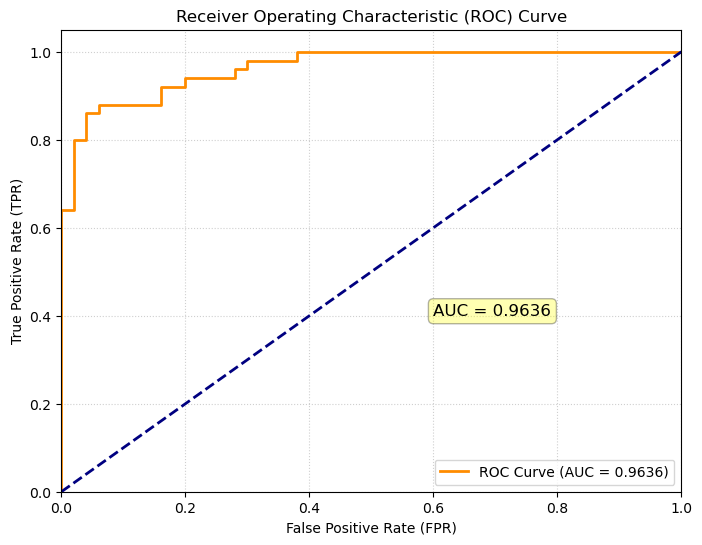

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    classification_report, 
    roc_curve, 
    roc_auc_score
)

# Example classification setup: Predicting high profit (1 if profit > median else 0)
y_clf = (df['profit'] > df['profit'].median()).astype(int)
X = df[['quantity', 'unit_price', 'discount_pct', 'sales_amount']]

X_train, X_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check class distributions
counts = y_clf_train.value_counts(normalize=True)
print("Class distribution in Training Set:\n", counts)

# Determine strategy dynamically
minority_ratio = counts.min()
if minority_ratio < 0.35:
    print(f"\nMinority class is {minority_ratio:.2%}. Addressing imbalance.")
    # Choice: Using class_weight='balanced' to avoid synthetic oversampling artifacts
    model_kwargs = {'class_weight': 'balanced', 'max_iter': 1000, 'random_state': 42}
    strategy_note = "Chosen Strategy: class_weight='balanced'. It shifts the loss function penalty to naturally account for minority instances without fabricating synthetic rows."
else:
    print(f"\nMinority class is {minority_ratio:.2%}. No critical imbalance strategy required.")
    model_kwargs = {'max_iter': 1000, 'random_state': 42}
    strategy_note = "Chosen Strategy: None required (balanced dataset)."

print(strategy_note)

# -------------------------------------------------------------
# 2. Model Training & Prediction
# -------------------------------------------------------------
clf_model = LogisticRegression(**model_kwargs)
clf_model.fit(X_train_scaled, y_clf_train)

# Predict labels and probabilities
y_pred_clf = clf_model.predict(X_test_scaled)
y_pred_prob = clf_model.predict_proba(X_test_scaled)[:, 1]

# -------------------------------------------------------------
# 3. Evaluation & Reports
# -------------------------------------------------------------
print("\n--- Confusion Matrix ---")
print(confusion_matrix(y_clf_test, y_pred_clf))

print("\n--- Classification Report ---")
print(classification_report(y_clf_test, y_pred_clf))

# -------------------------------------------------------------
# 4. ROC Curve & AUC Computation
# -------------------------------------------------------------
fpr, tpr, thresholds = roc_curve(y_clf_test, y_pred_prob)
auc_value = roc_auc_score(y_clf_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Annotate AUC value directly on the plot grid
plt.text(0.6, 0.4, f'AUC = {auc_value:.4f}', fontsize=12, 
         bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig("AUC curve.png")
plt.show()

In [34]:
# Defining features and creating a binary classification target
X = df[['quantity', 'unit_price', 'discount_pct', 'sales_amount']]
y = (df['profit'] > df['profit'].median()).astype(int)  # 1 for High Profit, 0 for Low Profit

# 2. Stratified Train-Test Split 
# (stratify ensures training and testing sets have the same class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Scale Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Crucial: Only transform test data, don't fit!

# 4. Initialize and Train Model
# Added max_iter=1000 to ensure the solver has enough iterations to converge
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Evaluate Performance
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy:  {test_accuracy:.4f}")

Training Accuracy: 0.8775
Testing Accuracy:  0.8800


# Decision-threshold sensitivity. 

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Generate predicted class probabilities for the positive class (1)
proba = model.predict_proba(X_test_scaled)[:, 1]

# 2. Define the thresholds
thresholds = np.arange(0.30, 0.80, 0.10)  # [0.3, 0.4, 0.5, 0.6, 0.7]

table_rows = []

# 3. Compute metrics at each threshold
for t in thresholds:
    # Convert probabilities to binary class predictions
    preds = (proba >= t).astype(int)
    
    # Calculate metrics
    precision = precision_score(y_test, preds, zero_division=0)
    recall = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    
    table_rows.append({
        "Threshold": f"{t:.4f}",
        "Precision": f"{precision:.4f}",
        "Recall": f"{recall:.4f}",
        "F1": f"{f1:.4f}"
    })

# 4. Print as a Markdown/Plain Text Table
df_metrics = pd.DataFrame(table_rows)
print(df_metrics.to_markdown(index=False))

|   Threshold |   Precision |   Recall |     F1 |
|------------:|------------:|---------:|-------:|
|         0.3 |      0.7656 |     0.98 | 0.8596 |
|         0.4 |      0.88   |     0.88 | 0.88   |
|         0.5 |      0.9524 |     0.8  | 0.8696 |
|         0.6 |      0.9722 |     0.7  | 0.814  |
|         0.7 |      0.9714 |     0.68 | 0.8    |


# Regularization experiment on Logistic Regression

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, roc_auc_score


# Create a dummy binary target for classification task demonstration 
df['target'] = (df['profit'] > df['profit'].median()).astype(int)

# Select numeric features for training
features = ['quantity', 'unit_price', 'discount_pct', 'sales_amount']
X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. Train Baseline Model (C=1.0) ---
model_baseline = LogisticRegression(C=1.0, random_state=42)
model_baseline.fit(X_train_scaled, y_train)
y_pred_base = model_baseline.predict(X_test_scaled)
y_prob_base = model_baseline.predict_proba(X_test_scaled)[:, 1]

# --- 3. Train Regularized Model (C=0.01) ---
model_reg = LogisticRegression(C=0.01, random_state=42)
model_reg.fit(X_train_scaled, y_train)
y_pred_reg = model_reg.predict(X_test_scaled)
y_prob_reg = model_reg.predict_proba(X_test_scaled)[:, 1]

# --- 4. Calculate Metrics ---
metrics = {
    'Baseline (C=1.0)': {
        'Precision': precision_score(y_test, y_pred_base),
        'Recall': recall_score(y_test, y_pred_base),
        'AUC': roc_auc_score(y_test, y_prob_base)
    },
    'Regularized (C=0.01)': {
        'Precision': precision_score(y_test, y_pred_reg),
        'Recall': recall_score(y_test, y_pred_reg),
        'AUC': roc_auc_score(y_test, y_prob_reg)
    }
}

# --- 5. Print Comparison Table ---
print(f"{'Model Configuration':<22} | {'Precision':<9} | {'Recall':<6} | {'AUC':<6}")
print("-" * 53)
for model_name, score in metrics.items():
    print(f"{model_name:<22} | {score['Precision']:.4f}    | {score['Recall']:.4f} | {score['AUC']:.4f}")

Model Configuration    | Precision | Recall | AUC   
-----------------------------------------------------
Baseline (C=1.0)       | 0.9464    | 0.7681 | 0.9596
Regularized (C=0.01)   | 0.9400    | 0.6812 | 0.9102


# Bootstrap confidence interval for AUC difference.

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Set random seed for reproducibility
np.random.seed(42)

# Create a binary classification target (e.g., High Profit: 1 if profit > median else 0)
median_profit = df['profit'].median()
df['is_high_profit'] = (df['profit'] > median_profit).astype(int)

# Select numeric features for classification
features = ['quantity', 'unit_price', 'discount_pct', 'sales_amount']
X = df[features]
y = df['is_high_profit']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_clf_test = np.array(y_test)

# 2. Train both models
model_c1 = LogisticRegression(C=1.0, random_state=42)
model_c1.fit(X_train_scaled, y_train)

model_c001 = LogisticRegression(C=0.01, random_state=42)
model_c001.fit(X_train_scaled, y_train)

# 3. Threshold Evaluation Table (C=1.0 Model)
proba_c1 = model_c1.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
table_data = []

for t in thresholds:
    preds = (proba_c1 >= t).astype(int)
    precision = precision_score(y_clf_test, preds, zero_division=0)
    recall = recall_score(y_clf_test, preds, zero_division=0)
    f1 = f1_score(y_clf_test, preds, zero_division=0)
    table_data.append([t, precision, recall, f1])

df_table = pd.DataFrame(table_data, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print("--- Threshold Evaluation Table ---")
print(df_table.to_markdown(index=False))
print("\n")

# 4. Bootstrap Analysis (C=1.0 vs C=0.01)
proba_c001 = model_c001.predict_proba(X_test_scaled)[:, 1]

n_iterations = 500
auc_differences = []
n_samples = len(y_clf_test)

for i in range(n_iterations):
    boot_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    
    y_boot = y_clf_test[boot_indices]
    proba_c1_boot = proba_c1[boot_indices]
    proba_c001_boot = proba_c001[boot_indices]
    
    if len(np.unique(y_boot)) < 2:
        continue
        
    auc_c1 = roc_auc_score(y_boot, proba_c1_boot)
    auc_c001 = roc_auc_score(y_boot, proba_c001_boot)
    
    auc_differences.append(auc_c1 - auc_c001)

mean_diff = np.mean(auc_differences)
lower_per = np.percentile(auc_differences, 2.5)
upper_per = np.percentile(auc_differences, 97.5)

print("--- Bootstrap Metrics ---")
print(f"Mean AUC Difference: {mean_diff:.4f}")
print(f"95% Confidence Interval: [{lower_per:.4f}, {upper_per:.4f}]")

--- Threshold Evaluation Table ---
|   Threshold |   Precision |   Recall |       F1 |
|------------:|------------:|---------:|---------:|
|         0.3 |    0.792683 | 0.942029 | 0.860927 |
|         0.4 |    0.888889 | 0.811594 | 0.848485 |
|         0.5 |    0.946429 | 0.768116 | 0.848    |
|         0.6 |    0.946429 | 0.768116 | 0.848    |
|         0.7 |    0.960784 | 0.710145 | 0.816667 |


--- Bootstrap Metrics ---
Mean AUC Difference: 0.0486
95% Confidence Interval: [0.0209, 0.0843]


In [38]:
import joblib

# Save variables to a dictionary file
data_dump = {
    'X_train_scaled': X_train_scaled,
    'X_test_scaled': X_test_scaled,
    'y_clf_train': y_clf_train,
    'y_clf_test': y_clf_test
}
joblib.dump(data_dump, 'processed_data.pkl')

['processed_data.pkl']